In [ ]:
"""
PCEC96          # Real Personal Consumption Expenditures (for target generation)
FEDFUNDS        # Federal Funds Effective Rate (Policy Rate)
CPIAUCSL        # Consumer Price Index (Headline CPI)
CPILFESL        # Core Consumer Price Index
UNRATE          # Unemployment Rate
DSPIC96         # Real Disposable Personal Income

Unused:
DTB3            # 3-Month Treasury Bill Rate (Short-term Rate)
DGS10           # 10-Year Treasury Constant Maturity Rate (Long-term Rate)
PAYEMS          # Nonfarm Payrolls (Employment)
UMCSENT         # University of Michigan: Consumer Sentiment

DATE
PCEC96          # 소비 (target 생성용)
FEDFUNDS        # 기준금리
DTB3            # 단기금리
DGS10           # 장기금리
CPIAUCSL        # CPI
CPILFESL        # Core CPI
UNRATE          # 실업률
PAYEMS          # 고용
DSPIC96         # 실질 가처분소득
UMCSENT         # (선택)
"""

'\nDATE\nPCEC96          # 소비 (target 생성용)\nFEDFUNDS        # 기준금리\nDTB3            # 단기금리\nDGS10           # 장기금리\nCPIAUCSL        # CPI\nCPILFESL        # Core CPI\nUNRATE          # 실업률\nPAYEMS          # 고용\nDSPIC96         # 실질 가처분소득\nUMCSENT         # (선택)\n'

In [158]:
import pandas as pd
from sklearn.linear_model import Ridge
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
import missingno as msno
import glob
from sklearn.metrics import mean_squared_error, r2_score

In [159]:
def load_series(path, col_name):
    df = pd.read_csv(path) 
    df.columns = ["DATE", col_name]
    df["DATE"] = pd.to_datetime(df["DATE"])
    return df

In [160]:
pce       = load_series("./data/PCEC96.csv", "PCEC96")
fedfunds = load_series("./data/FEDFUNDS.csv", "FEDFUNDS")
cpi       = load_series("./data/CPIAUCSL.csv", "CPI")
core_cpi = load_series("./data/CPILFESL.csv", "CORE_CPI")
unrate   = load_series("./data/UNRATE.csv", "UNRATE")
payems   = load_series("./data/PAYEMS.csv", "PAYEMS")
income   = load_series("./data/DSPIC96.csv", "DSPIC96")
dtb3  = load_series("./data/DTB3.csv", "DTB3")
dgs10 = load_series("./data/DGS10.csv", "DGS10")

In [161]:
# Calculate yield spread
# Optional feature
"""
try:
    rates = pd.merge(dgs10, dtb3, on="DATE", how="inner")
    rates["YIELD_SPREAD"] = rates["DGS10"] - rates["DTB3"]
except:
    rates = None
"""

'\ntry:\n    rates = pd.merge(dgs10, dtb3, on="DATE", how="inner")\n    rates["YIELD_SPREAD"] = rates["DGS10"] - rates["DTB3"]\nexcept:\n    rates = None\n'

In [162]:
dfs = [pce, fedfunds, cpi, core_cpi, unrate, payems, income]

df = dfs[0]
for d in dfs[1:]:
    df = pd.merge(df, d, on="DATE", how="left")

# if rates is not None:
#     df = pd.merge(df, rates[["DATE", "YIELD_SPREAD"]], on="DATE", how="left")

df = df.sort_values("DATE").reset_index(drop=True)

In [163]:
"""
Natural log is commonly used in measuring rate of change economics and finance.
While percentage changes must be multiplied to combine multiple periods, 
log changes only need to be summed, which makes multi-period analysis much simpler.
For small changes, log changes are very close to percentage changes, so they provide a convenient and reliable way to measure growth rates.
"""

df["log_PCE"] = np.log(df["PCEC96"])

# change of log_PCE, create target y
df["3m_PCE_change"] = df["log_PCE"].shift(-3) - df["log_PCE"]

# df["FEDFUNDS_d1"] = df["FEDFUNDS"].diff(1)
# df["UNRATE_d1"]   = df["UNRATE"].diff(1) 
df["CPI_d1"]      = np.log(df["CPI"]).diff(1)    
df["CORE_CPI_d1"] = np.log(df["CORE_CPI"]).diff(1)
df["DSPIC96_d1"]  = np.log(df["DSPIC96"]).diff(1)

In [164]:
lag_cols = ["FEDFUNDS", "UNRATE"]
lag_d1_cols = ["CPI_d1", "CORE_CPI_d1", "DSPIC96_d1"]

# 1m, 3m lag features
for col in lag_cols:
    df[f"{col}_lag1"] = df[col].shift(1)
    #df[f"{col}_lag3"] = df[col].shift(3)

for col in lag_d1_cols:
    df[f"{col}_lag1"] = df[col].shift(1)
    #df[f"{col}_lag3"] = df[col].shift(3)

# if "YIELD_SPREAD" in df.columns:
#     df["YIELD_SPREAD_lag1"] = df["YIELD_SPREAD"].shift(1)

In [165]:
# automatically include all lag features
features = [c for c in df.columns if c.endswith("_lag1") or c.endswith("_lag3")]
features = sorted(features)  

model_df = df[["DATE", "3m_PCE_change"] + features].dropna().reset_index(drop=True)
print("Num features:", len(features))
print(model_df.head())

Num features: 5
        DATE  3m_PCE_change  CORE_CPI_d1_lag1  CPI_d1_lag1  DSPIC96_d1_lag1  \
0 2007-03-01       0.002481          0.002561     0.003871         0.003290   
1 2007-04-01       0.004552          0.001352     0.005187         0.003254   
2 2007-05-01       0.007292          0.001570     0.002996         0.001470   
3 2007-06-01       0.008088          0.001482     0.004124         0.000589   
4 2007-07-01       0.005848          0.001589     0.002314        -0.000547   

   FEDFUNDS_lag1  UNRATE_lag1  
0           5.26          4.5  
1           5.26          4.4  
2           5.25          4.5  
3           5.25          4.4  
4           5.25          4.6  


In [166]:
print(model_df.tail())
print(model_df.info())

          DATE  3m_PCE_change  CORE_CPI_d1_lag1  CPI_d1_lag1  DSPIC96_d1_lag1  \
215 2025-02-01       0.007757          0.004453     0.004658         0.001225   
216 2025-03-01       0.002578          0.002264     0.002157         0.001156   
217 2025-04-01       0.006285          0.000565    -0.000500         0.006600   
218 2025-05-01       0.010629          0.002365     0.002206         0.005741   
219 2025-06-01       0.009134          0.001298     0.000808        -0.008418   

     FEDFUNDS_lag1  UNRATE_lag1  
215           4.33          4.0  
216           4.33          4.2  
217           4.33          4.2  
218           4.33          4.2  
219           4.33          4.3  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DATE              220 non-null    datetime64[ns]
 1   3m_PCE_change     220 non-null    floa

In [167]:
SPLIT_DATE = pd.Timestamp("2020-01-01")

train_df = model_df[model_df["DATE"] < SPLIT_DATE].copy() 
test_df  = model_df[model_df["DATE"] >= SPLIT_DATE].copy()

X_train = train_df[features]                               
y_train = train_df["3m_PCE_change"]                         

X_test  = test_df[features]                                 
y_test  = test_df["3m_PCE_change"]                           

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Train date range:", train_df["DATE"].min(), "to", train_df["DATE"].max())
print("Test date range:",  test_df["DATE"].min(),  "to", test_df["DATE"].max()) 


Train rows: 154 Test rows: 66
Train date range: 2007-03-01 00:00:00 to 2019-12-01 00:00:00
Test date range: 2020-01-01 00:00:00 to 2025-06-01 00:00:00


In [168]:
scaler = StandardScaler()                     
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)              

In [169]:
# Ridge
for a in [0.1, 1.0, 5.0, 10.0]:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"alpha={a}, RMSE={rmse:.4f}, R2={r2:.4f}")

alpha=0.1, RMSE=0.0353, R2=-0.0144
alpha=1.0, RMSE=0.0353, R2=-0.0142
alpha=5.0, RMSE=0.0353, R2=-0.0133
alpha=10.0, RMSE=0.0353, R2=-0.0124


In [170]:
coef = pd.Series(model.coef_, index=features).sort_values()
print(coef)

FEDFUNDS_lag1      -0.001163
UNRATE_lag1        -0.000625
CORE_CPI_d1_lag1   -0.000382
CPI_d1_lag1         0.000110
DSPIC96_d1_lag1     0.000124
dtype: float64


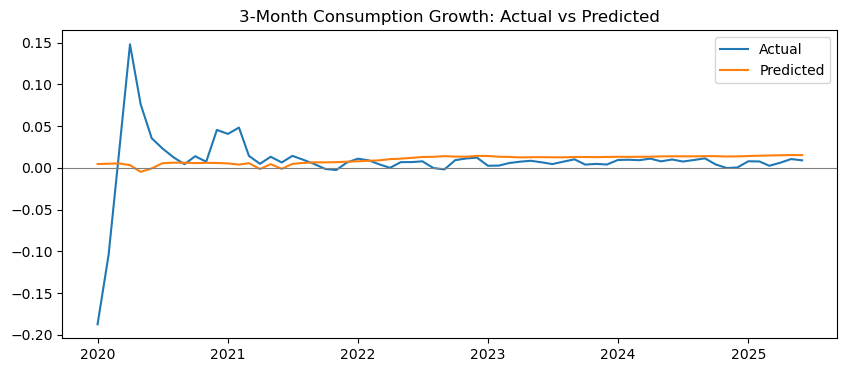

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(result_df["DATE"], result_df["3m_PCE_change"], label="Actual")
plt.plot(result_df["DATE"], result_df["predicted"], label="Predicted") 
plt.axhline(0, color="gray", linewidth=0.8)                            
plt.legend()
plt.title("3-Month Consumption Growth: Actual vs Predicted")
plt.show()
